# DSN AI Bootcamp Qualification Hackathon 2026
## Product Sales Prediction — ML Track

**Author:** Ibrahim Yisau

**Objective:** Predict `total_sales` for product–store combinations in the test set, using historical product, store and pricing information from the training set.

**Workflow:** Understand → Analyse → Prepare → Model → Validate → Tune → Predict → Communicate

**Note on reproducibility:** This notebook expects `train.csv`, `test.csv` and `sample_submission.csv` in the working directory (as provided by the competition) and runs sequentially from top to bottom.

## 1. Problem Overview

The task is a supervised regression problem: predict `total_sales` for each row in the test set, where a row represents a specific product sold in a specific store.

The training data contains 13 columns (12 features + the `total_sales` target) and the test data contains the same 12 features without the target. A `sample_submission.csv` file defines the expected submission format: an `id` column and a predicted `total_sales` column.

The modelling approach used throughout this notebook is **CatBoost**, a gradient-boosted decision tree algorithm that natively supports categorical features — a reasonable choice given that several of the predictors (product category, store format, store location tier, etc.) are categorical. Whether CatBoost outperforms alternative approaches is assessed empirically in the model comparison (Section 7), not assumed here.

## 2. Data Loading and Initial Inspection

In [1]:
import pandas as pd
import numpy as np

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

print("TRAIN:", train.shape)
print("TEST:", test.shape)
print("SAMPLE SUBMISSION:", sample_submission.shape)

print("\nTrain columns:")
print(train.columns.tolist())

print("\nTest columns:")
print(test.columns.tolist())

print("\nSample submission columns:")
print(sample_submission.columns.tolist())

TRAIN: (6818, 13)
TEST: (1705, 12)
SAMPLE SUBMISSION: (1705, 2)

Train columns:
['id', 'product_code', 'product_weight_kg', 'fat_content', 'shelf_visibility', 'product_category', 'product_price', 'store_code', 'store_age_years', 'store_size', 'store_location_tier', 'store_format', 'total_sales']

Test columns:
['id', 'product_code', 'product_weight_kg', 'fat_content', 'shelf_visibility', 'product_category', 'product_price', 'store_code', 'store_age_years', 'store_size', 'store_location_tier', 'store_format']

Sample submission columns:
['id', 'total_sales']


The training set has 6,818 rows and 13 columns (12 predictors + `total_sales`). The test set has 1,705 rows and the same 12 predictors. The sample submission confirms the required output format: `id` and `total_sales`.

In [2]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   6818 non-null   object 
 1   product_code         6818 non-null   object 
 2   product_weight_kg    5593 non-null   float64
 3   fat_content          6818 non-null   object 
 4   shelf_visibility     6818 non-null   float64
 5   product_category     6818 non-null   object 
 6   product_price        6818 non-null   float64
 7   store_code           6818 non-null   object 
 8   store_age_years      6818 non-null   int64  
 9   store_size           4899 non-null   object 
 10  store_location_tier  6818 non-null   object 
 11  store_format         6818 non-null   object 
 12  total_sales          6818 non-null   float64
dtypes: float64(4), int64(1), object(8)
memory usage: 692.6+ KB


In [3]:
# Missing values
missing = train.isnull().sum()

missing_summary = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": (missing / len(train)) * 100
})

missing_summary[missing_summary["missing_count"] > 0]

,missing_count,missing_percent
product_weight_kg,1225,17.967146
store_size,1919,28.146084


Two columns have missing values: `product_weight_kg` (18% missing) and `store_size` (28% missing). Both are handled explicitly during data preparation (Section 4).

In [4]:
# Duplicate rows
print("Number of duplicate rows:", train.duplicated().sum())

Number of duplicate rows: 0


In [5]:
# Number of unique values in each column
train.nunique().sort_values()

,0
fat_content,2
store_size,3
store_location_tier,3
store_format,4
store_age_years,9
store_code,10
product_category,48
product_code,1555
shelf_visibility,1732
product_weight_kg,4675


There are no fully duplicate rows in the training set. `product_code` has 1,555 unique values and `product_category` has 48 unique raw values — noticeably more than expected, which is investigated next. (This check is at the row level; the uniqueness of product–store *combinations* is examined separately in Section 3.7.)

## 3. Exploratory Data Analysis

### 3.1 Categorical variables

In [6]:
categorical_cols = [
    "product_code",
    "fat_content",
    "product_category",
    "store_code",
    "store_size",
    "store_location_tier",
    "store_format"
]

for col in categorical_cols:
    print(f"\n{'='*50}")
    print(col)
    print("Unique values:", train[col].nunique())
    print(train[col].value_counts(dropna=False).head(10))


product_code
Unique values: 1555
product_code
PRD-YZB4K8    9
PRD-U02KQN    8
PRD-8INI8M    8
PRD-U438R9    8
PRD-ONGWUL    8
PRD-1RUPFR    8
PRD-8A5PN4    8
PRD-1ZL2WT    8
PRD-MH7GX8    8
PRD-N5F62D    8
Name: count, dtype: int64

fat_content
Unique values: 2
fat_content
Low Fat    4425
Regular    2393
Name: count, dtype: int64

product_category
Unique values: 48
product_category
Fruits and Vegetables    480
Snack Foods              468
Household                387
Frozen Foods             326
Canned                   271
Dairy                    269
fruits and vegetables    265
FRUITS AND VEGETABLES    261
Baking Goods             254
snack foods              236
Name: count, dtype: int64

store_code
Unique values: 10
store_code
STORE-YLW    754
STORE-9RG    752
STORE-AGY    748
STORE-7WS    748
STORE-OYG    744
STORE-HL7    742
STORE-DKU    736
STORE-89Z    728
STORE-JOR    439
STORE-T5G    427
Name: count, dtype: int64

store_size
Unique values: 3
store_size
Medium    2218
Small 

In [7]:
print(train["product_category"].value_counts(dropna=False))

product_category
Fruits and Vegetables    480
Snack Foods              468
Household                387
Frozen Foods             326
Canned                   271
Dairy                    269
fruits and vegetables    265
FRUITS AND VEGETABLES    261
Baking Goods             254
snack foods              236
SNACK FOODS              229
Health and Hygiene       197
HOUSEHOLD                185
Soft Drinks              178
frozen foods             177
FROZEN FOODS             172
household                168
Meat                     157
DAIRY                    143
dairy                    142
BAKING GOODS             137
canned                   129
baking goods             125
CANNED                   117
health and hygiene       116
Breads                   110
SOFT DRINKS              100
HEALTH AND HYGIENE        99
MEAT                      94
Hard Drinks               92
soft drinks               88
meat                      88
Others                    73
Starchy Foods             

`product_category` has 48 raw unique values. Inspecting the values shows this is inflated by inconsistent capitalisation and stray whitespace (e.g. `"Fruits and Vegetables"`, `"fruits and vegetables"`, `"FRUITS AND VEGETABLES"` appear as separate raw values but represent the same underlying category once formatting is normalised). This is standardised during data preparation (Section 4).

### 3.2 Target distribution

In [8]:
train["total_sales"].describe()

,total_sales
count,6818.000000
mean,2174.756574
std,1697.894956
min,32.700000
25%,834.792500
50%,1790.890000
75%,3092.587500
max,12996.820000


In [9]:
train["total_sales"].skew()

np.float64(1.1539947519138116)

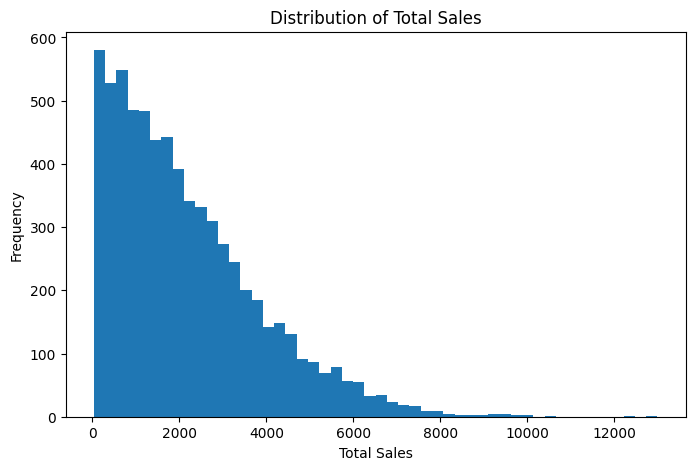

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(train["total_sales"], bins=50)
plt.xlabel("Total Sales")
plt.ylabel("Frequency")
plt.title("Distribution of Total Sales")
plt.show()

`total_sales` ranges from about 33 to 12,997, with a right-skewed distribution (skewness ≈ 1.15). A log-transformed target was tested as a modelling strategy in Section 6 to address this skew.

### 3.3 Numerical features

In [11]:
numerical_cols = [
    "product_weight_kg",
    "shelf_visibility",
    "product_price",
    "store_age_years"
]

train[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
product_weight_kg,5593.0,12.850876,4.646542,4.482,8.7500,12.6470,16.8940,21.8830
shelf_visibility,6818.0,0.065527,0.051566,0.000,0.0266,0.0532,0.0934,0.3201
product_price,6818.0,140.473623,62.413513,31.110,93.2800,142.0650,185.9875,273.0400
store_age_years,6818.0,34.178205,8.384574,23.000,28.0000,33.0000,45.0000,47.0000


In [12]:
for col in numerical_cols:
    print(f"\n{col}")
    print("Correlation with total_sales:",
          train[[col, "total_sales"]].corr().iloc[0, 1])


product_weight_kg
Correlation with total_sales: 0.015531995931369816

shelf_visibility
Correlation with total_sales: -0.1181238764297222

product_price
Correlation with total_sales: 0.5698334561303238

store_age_years
Correlation with total_sales: 0.0394427874183061


`product_price` has the strongest linear correlation with `total_sales` (≈ 0.57). `shelf_visibility`, `product_weight_kg` and `store_age_years` show weak linear correlation individually. Correlation coefficients only capture linear, pairwise relationships — they do not establish predictive importance or causation, and a feature can still be useful to a model through non-linear effects or interactions with other features. This is part of the motivation for using a tree-based model, which can capture such relationships even where simple pairwise correlation does not show them.

### 3.4 Categorical relationships with total sales

In [13]:
categorical_cols_summary = [
    "fat_content",
    "product_category",
    "store_size",
    "store_location_tier",
    "store_format"
]

for col in categorical_cols_summary:
    print(f"\n{'='*60}")
    print(col)

    summary = (
        train.groupby(col, dropna=False)["total_sales"]
        .agg(["count", "mean", "median", "std"])
        .sort_values("mean", ascending=False)
    )

    print(summary)


fat_content
             count         mean  median          std
fat_content                                         
Regular       2393  2218.379323  1848.8  1707.076497
Low Fat       4425  2151.165785  1761.1  1692.633895

product_category
                       count         mean    median          std
product_category                                                
seafood                   14  2837.669286  2683.005  2166.050850
STARCHY FOODS             30  2419.785333  2049.325  1768.174333
Starchy Foods             59  2404.877627  2037.090  1656.753099
starchy foods             24  2399.619167  1960.055  1961.053321
FRUITS AND VEGETABLES    261  2381.811379  1873.450  1856.298062
dairy                    142  2374.590141  1796.840  1937.573686
Meat                     157  2372.897261  1883.860  1869.289999
fruits and vegetables    265  2328.098868  1961.090  1760.319230
canned                   129  2309.617132  1894.880  1565.956903
household                168  2304.512500 

Categorical variables exhibit differences in observed sales distributions across their levels, providing potentially useful signal for a categorical-aware model. This is a descriptive observation from the grouped summaries, not evidence on its own that CatBoost outperforms alternative approaches — that comparison is made directly in Section 7.

### 3.5 Store-level structure

In [14]:
store_sales = (
    train.groupby("store_code")["total_sales"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("mean", ascending=False)
)

store_sales

,count,mean,median,std
store_code,,,,
STORE-7WS,748,3660.182219,3348.085,2070.097702
STORE-9RG,752,2479.168098,2139.320,1553.797046
STORE-89Z,728,2365.926745,2003.490,1518.177714
STORE-OYG,744,2365.833656,2018.895,1566.741909
STORE-AGY,748,2254.890120,1998.725,1501.401983
STORE-YLW,754,2253.950690,1902.455,1488.222137
STORE-DKU,736,2177.136481,1863.030,1446.586133
STORE-HL7,742,1971.661954,1622.170,1397.518220
STORE-T5G,427,338.326651,260.820,254.819146


In [15]:
# Check store_size missingness by store
store_size_missing = (
    train.groupby("store_code")["store_size"]
    .agg(
        total_rows="size",
        missing_count=lambda x: x.isna().sum(),
        missing_percent=lambda x: x.isna().mean() * 100
    )
)

store_size_missing

,total_rows,missing_count,missing_percent
store_code,,,
STORE-7WS,748,0,0.0
STORE-89Z,728,0,0.0
STORE-9RG,752,0,0.0
STORE-AGY,748,0,0.0
STORE-DKU,736,736,100.0
STORE-HL7,742,0,0.0
STORE-JOR,439,439,100.0
STORE-OYG,744,744,100.0
STORE-T5G,427,0,0.0


Store-level average sales vary considerably across the 10 stores. The pattern suggests that `store_size` missingness may be associated with particular stores rather than being uniformly distributed, though the underlying cause of the missingness is not established by this analysis alone.

### 3.6 Product-level structure

In [16]:
# Check product weight missingness by product
product_weight_missing = (
    train.groupby("product_code")["product_weight_kg"]
    .agg(
        total_rows="size",
        missing_count=lambda x: x.isna().sum(),
        missing_percent=lambda x: x.isna().mean() * 100
    )
)

product_weight_missing.sort_values(
    "missing_percent",
    ascending=False
).head(10)

,total_rows,missing_count,missing_percent
product_code,,,
PRD-MRKSQJ,1,1,100.000000
PRD-QIGCT2,1,1,100.000000
PRD-NBDVPI,1,1,100.000000
PRD-7JH2LK,1,1,100.000000
PRD-8CL0LC,1,1,100.000000
PRD-DH3TKZ,1,1,100.000000
PRD-DQHDK3,1,1,100.000000
PRD-M80O2R,1,1,100.000000
PRD-MW0SKC,3,2,66.666667


In [17]:
product_consistency = train.groupby("product_code").agg(
    observations=("product_code", "size"),
    unique_weight=("product_weight_kg", "nunique"),
    unique_fat=("fat_content", "nunique"),
    unique_category=("product_category", "nunique"),
    unique_price=("product_price", "nunique")
)

print("Products with multiple prices:", (product_consistency["unique_price"] > 1).sum())
print("Products with multiple categories:", (product_consistency["unique_category"] > 1).sum())
print("Products with multiple fat labels:", (product_consistency["unique_fat"] > 1).sum())

Products with multiple prices: 1509
Products with multiple categories: 1392
Products with multiple fat labels: 0


Among the 1,555 products in the training data, the consistency check above finds 0 products with more than one distinct `product_category` value and 0 products with more than one distinct `fat_content` value — i.e. in this dataset, category and fat-content labels are consistent within each product. Price varies across most products (1,509 out of 1,555 have more than one distinct price), reflecting store-specific pricing. This supports treating `product_price` as a row-level feature rather than a fixed product attribute.

### 3.7 Product–store structure and train/test overlap

In [18]:
# Unique product-store combinations
product_store_counts = (
    train
    .groupby(["product_code", "store_code"])
    .size()
    .reset_index(name="count")
)

print("Unique product-store combinations:", len(product_store_counts))
print("Total training rows:", len(train))
print("Maximum possible product-store combinations:",
      train["product_code"].nunique() * train["store_code"].nunique())

Unique product-store combinations: 6818
Total training rows: 6818
Maximum possible product-store combinations: 15550


In [19]:
train_products = set(train["product_code"])
test_products = set(test["product_code"])

train_stores = set(train["store_code"])
test_stores = set(test["store_code"])

train_pairs = set(zip(train["product_code"], train["store_code"]))
test_pairs = set(zip(test["product_code"], test["store_code"]))

print("Products in train:", len(train_products), "| in test:", len(test_products),
      "| test products seen in train:", len(test_products.intersection(train_products)))

print("Stores in train:", len(train_stores), "| in test:", len(test_stores),
      "| test stores seen in train:", len(test_stores.intersection(train_stores)))

print("Test product-store combinations:", len(test_pairs),
      "| already seen in training:", len(test_pairs.intersection(train_pairs)))

Products in train: 1555 | in test: 1082 | test products seen in train: 1078
Stores in train: 10 | in test: 10 | test stores seen in train: 10
Test product-store combinations: 1705 | already seen in training: 0


Each training row is a unique product–store combination (no repeats). All 10 stores in the test set were also seen in training, and the large majority of test products (1,078 of 1,082) were seen in training, with only 4 completely new products. However, **none of the test product–store combinations were seen in training** — every test row asks the model to predict for a product–store pairing it has not observed before, so the model cannot simply memorise a specific pairing's historical sales. This is an important consideration for feature design and evaluation, though it does not by itself determine which features or modelling strategy will work best.

## 4. Data Preparation

The steps below are the cleaning steps applied consistently before any modelling, and are carried forward through the rest of the notebook:

- The original `train`/`test` DataFrames are preserved unmodified; all cleaning is done on copies (`train_clean`, `test_clean`).
- `product_category` is standardised by stripping whitespace and lowercasing, which collapses the 48 raw categories into their true underlying set.
- Categorical missing values are filled with an explicit `"Missing"` string category where required by CatBoost, rather than being dropped or imputed with a statistic. This lets the model learn whether missingness itself is informative.
- No numerical scaling is applied, since CatBoost (a tree-based model) does not require feature scaling.
- Train and test feature columns are kept aligned throughout.

This is distinct from the **experimental feature transformations** (missing-weight indicator, product-level aggregates, interaction features, log-transformed target) tested in Section 6 — those were evaluated as alternatives and are not part of this baseline preprocessing pipeline or the final model's feature set.

In [20]:
# Keep the original data untouched
train_clean = train.copy()
test_clean = test.copy()

# Standardize product category (strip whitespace, lowercase)
train_clean["product_category"] = train_clean["product_category"].str.strip().str.lower()
test_clean["product_category"] = test_clean["product_category"].str.strip().str.lower()

print("Original product categories:", train["product_category"].nunique())
print("Cleaned product categories:", train_clean["product_category"].nunique())
print("\nCleaned categories:")
print(sorted(train_clean["product_category"].unique()))

Original product categories: 48
Cleaned product categories: 16

Cleaned categories:
['baking goods', 'breads', 'breakfast', 'canned', 'dairy', 'frozen foods', 'fruits and vegetables', 'hard drinks', 'health and hygiene', 'household', 'meat', 'others', 'seafood', 'snack foods', 'soft drinks', 'starchy foods']


Standardising capitalisation reduces `product_category` from 48 raw values down to its true set of underlying categories.

## 5. Baseline Model

The initial modelling approach used a single 80/20 train-validation split (random state 42) to get a quick read on model performance before moving to a more robust cross-validation strategy (Section 6). This is a single holdout estimate, not the final estimate of generalization performance — the more robust 5-fold cross-validation estimate is introduced in Section 6.4.

> **The row identifier `id` was excluded from model training and retained only for submission identification.**

In [21]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = train_clean.drop(columns=["total_sales"])
y = train_clean["total_sales"]

# 80/20 train-validation split
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set:", X_train.shape)
print("Validation set:", X_valid.shape)

Training set: (5454, 12)
Validation set: (1364, 12)


In [22]:
# Remove the row identifier from the model features
X_train_model = X_train.drop(columns=["id"])
X_valid_model = X_valid.drop(columns=["id"])

categorical_features = X_train_model.select_dtypes(include=["object"]).columns.tolist()

print("Features used for modelling:")
print(X_train_model.columns.tolist())
print("\nCategorical features:")
print(categorical_features)

Features used for modelling:
['product_code', 'product_weight_kg', 'fat_content', 'shelf_visibility', 'product_category', 'product_price', 'store_code', 'store_age_years', 'store_size', 'store_location_tier', 'store_format']

Categorical features:
['product_code', 'fat_content', 'product_category', 'store_code', 'store_size', 'store_location_tier', 'store_format']


In [23]:
# Convert missing categorical values to an explicit category
X_train_cb = X_train_model.copy()
X_valid_cb = X_valid_model.copy()

for col in categorical_features:
    X_train_cb[col] = X_train_cb[col].fillna("Missing").astype(str)
    X_valid_cb[col] = X_valid_cb[col].fillna("Missing").astype(str)

In [24]:
!pip install catboost
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error

baseline_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=100
)

baseline_model.fit(
    X_train_cb,
    y_train,
    cat_features=categorical_features,
    eval_set=(X_valid_cb, y_valid),
    use_best_model=True
)

y_valid_pred = baseline_model.predict(X_valid_cb)
baseline_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred))

print(f"Baseline Validation RMSE: {baseline_rmse:.4f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.8 MB/s eta 0:00:00
0:	learn: 1648.1780435	test: 1672.2676541	best: 1672.2676541 (0)	total: 63.4ms	remaining: 31.6s
100:	learn: 1058.2025554	test: 1067.3355559	best: 1067.3355559 (100)	total: 1.28s	remaining: 5.05s
200:	learn: 1034.2200866	test: 1066.5767863	best: 1065.4282951 (153)	total: 2.82s	remaining: 4.19s
300:	learn: 1014.3434751	test: 1067.3743509	best: 1065.4282951 (153)	total: 4.84s	remaining: 3.2s
400:	learn: 989.7079812	test: 1070.8429985	best: 1065.4282951 (153)	total: 6.44s	remaining: 1.59s
499:	learn: 967.5133368	test: 1075.1877742	best: 1065.4282951 (153)	total: 7.7s	remaining: 0us

bestTest = 1065.428295
bestIteration = 153

Shrink model to first 154 iterations.
Baseline Validation RMSE: 1065.4283


The baseline CatBoost model (depth 6, 500 iterations, learning rate 0.05) achieved a single 80/20 holdout validation RMSE of **1065.4283**.

## 6. Model Development and Validation

Starting from the baseline, several modelling variations were tested on the same 80/20 split to see whether they improved validation RMSE. This section summarises those experiments.

### 6.1 Increasing tree depth

In [25]:
model_v2 = CatBoostRegressor(
    iterations=700,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=100
)

model_v2.fit(
    X_train_cb,
    y_train,
    cat_features=categorical_features,
    eval_set=(X_valid_cb, y_valid),
    use_best_model=True
)

y_valid_pred_v2 = model_v2.predict(X_valid_cb)
rmse_v2 = np.sqrt(mean_squared_error(y_valid, y_valid_pred_v2))

print(f"Model V2 (depth 8) Validation RMSE: {rmse_v2:.4f}")

0:	learn: 1648.2919007	test: 1672.2673674	best: 1672.2673674 (0)	total: 28.6ms	remaining: 20s
100:	learn: 1042.7360131	test: 1065.3348295	best: 1065.3348295 (100)	total: 2.46s	remaining: 14.6s
200:	learn: 989.7639867	test: 1065.9446089	best: 1064.4032801 (119)	total: 7.55s	remaining: 18.7s
300:	learn: 953.2529519	test: 1070.5085172	best: 1064.4032801 (119)	total: 14.7s	remaining: 19.5s
400:	learn: 910.3883676	test: 1072.9116628	best: 1064.4032801 (119)	total: 20.2s	remaining: 15.1s
500:	learn: 862.7691181	test: 1077.9796833	best: 1064.4032801 (119)	total: 24.9s	remaining: 9.9s
600:	learn: 815.7710351	test: 1080.5906974	best: 1064.4032801 (119)	total: 27.7s	remaining: 4.57s
699:	learn: 774.3372754	test: 1085.0766160	best: 1064.4032801 (119)	total: 30.1s	remaining: 0us

bestTest = 1064.40328
bestIteration = 119

Shrink model to first 120 iterations.
Model V2 (depth 8) Validation RMSE: 1064.4033


Increasing depth from 6 to 8 (V2) tests whether additional model complexity improves the holdout result. The resulting RMSE (1064.4033) is about 1 point lower than the baseline (1065.4283) on this single 80/20 split — a small difference relative to the fold-to-fold variation seen later in cross-validation (std ≈ 19.4), so it should not be read as a large or decisive improvement on its own. It is nonetheless the configuration carried forward into the feature-engineering experiments and later cross-validation.

### 6.2 Additional feature-engineering experiments

Three further ideas were tested against the same validation split: an explicit missing-weight indicator, product-level aggregate statistics (computed from training data only, to avoid leakage), and a log-transformed target. Each is implemented concisely below; full diagnostic output has been trimmed since the outcome of each experiment is what matters for the final decision.

In [26]:
# --- Missing product-weight indicator ---
X_train_v3 = X_train_model.copy()
X_valid_v3 = X_valid_model.copy()

X_train_v3["product_weight_missing"] = X_train_v3["product_weight_kg"].isna().astype(int)
X_valid_v3["product_weight_missing"] = X_valid_v3["product_weight_kg"].isna().astype(int)

for col in categorical_features:
    X_train_v3[col] = X_train_v3[col].fillna("Missing").astype(str)
    X_valid_v3[col] = X_valid_v3[col].fillna("Missing").astype(str)

model_v3 = CatBoostRegressor(
    iterations=700, learning_rate=0.05, depth=6,
    loss_function="RMSE", eval_metric="RMSE", random_seed=42, verbose=False
)
model_v3.fit(X_train_v3, y_train, cat_features=categorical_features,
             eval_set=(X_valid_v3, y_valid), use_best_model=True)

rmse_v3 = np.sqrt(mean_squared_error(y_valid, model_v3.predict(X_valid_v3)))
print(f"Model V3 (missing-weight indicator) Validation RMSE: {rmse_v3:.4f}")

Model V3 (missing-weight indicator) Validation RMSE: 1067.8711


In [27]:
# --- Product-level aggregate features (computed from training data only) ---
product_stats = X_train_model.groupby("product_code").agg(
    product_observation_count=("product_code", "size"),
    product_mean_price=("product_price", "mean"),
    product_price_std=("product_price", "std"),
    product_mean_weight=("product_weight_kg", "mean"),
    product_weight_std=("product_weight_kg", "std")
).reset_index()

product_stats[["product_price_std", "product_weight_std"]] = (
    product_stats[["product_price_std", "product_weight_std"]].fillna(0)
)

X_train_fe = X_train_model.merge(product_stats, on="product_code", how="left")
X_valid_fe = X_valid_model.merge(product_stats, on="product_code", how="left")

categorical_features_fe = X_train_fe.select_dtypes(include=["object"]).columns.tolist()
for col in categorical_features_fe:
    X_train_fe[col] = X_train_fe[col].fillna("Missing").astype(str)
    X_valid_fe[col] = X_valid_fe[col].fillna("Missing").astype(str)

model_v4 = CatBoostRegressor(
    iterations=700, learning_rate=0.05, depth=6,
    loss_function="RMSE", eval_metric="RMSE", random_seed=42, verbose=False
)
model_v4.fit(X_train_fe, y_train, cat_features=categorical_features_fe,
             eval_set=(X_valid_fe, y_valid), early_stopping_rounds=80)

v4_rmse = np.sqrt(mean_squared_error(y_valid, model_v4.predict(X_valid_fe)))
print(f"Model V4 (product-level features) Validation RMSE: {v4_rmse:.4f}")

Model V4 (product-level features) Validation RMSE: 1079.9103


Validation products not present in the training split receive missing values for the product-level aggregate features because those statistics can only be computed for products observed in the training portion. CatBoost can handle these numeric missing values directly. This is an inherent limitation of product-level aggregate features when predicting for unseen products, consistent with the train/test overlap finding in Section 3.7.

In [28]:
# --- Numeric and categorical interaction features ---
X_train_v5 = X_train_model.copy()
X_valid_v5 = X_valid_model.copy()

for df in [X_train_v5, X_valid_v5]:
    df["price_x_shelf_visibility"] = df["product_price"] * df["shelf_visibility"]
    df["price_x_store_age"] = df["product_price"] * df["store_age_years"]
    df["shelf_visibility_x_store_age"] = df["shelf_visibility"] * df["store_age_years"]
    df["price_per_store_age"] = df["product_price"] / (df["store_age_years"] + 1)
    df["store_format_x_location"] = df["store_format"].astype(str) + "_" + df["store_location_tier"].astype(str)
    df["store_format_x_size"] = df["store_format"].astype(str) + "_" + df["store_size"].astype(str)
    df["store_location_x_size"] = df["store_location_tier"].astype(str) + "_" + df["store_size"].astype(str)

categorical_features_v5 = X_train_v5.select_dtypes(include=["object"]).columns.tolist()
for col in categorical_features_v5:
    X_train_v5[col] = X_train_v5[col].fillna("Missing").astype(str)
    X_valid_v5[col] = X_valid_v5[col].fillna("Missing").astype(str)

model_v5 = CatBoostRegressor(
    iterations=700, learning_rate=0.05, depth=8,
    loss_function="RMSE", eval_metric="RMSE", random_seed=42, verbose=False
)
model_v5.fit(X_train_v5, y_train, cat_features=categorical_features_v5,
             eval_set=(X_valid_v5, y_valid), early_stopping_rounds=80)

v5_rmse = np.sqrt(mean_squared_error(y_valid, model_v5.predict(X_valid_v5)))
print(f"Model V5 (interaction features) Validation RMSE: {v5_rmse:.4f}")

Model V5 (interaction features) Validation RMSE: 1072.2665


In [29]:
# --- Log-transformed target ---
y_train_log = np.log1p(y_train)
y_valid_log = np.log1p(y_valid)

model_v6 = CatBoostRegressor(
    iterations=700, learning_rate=0.05, depth=8,
    loss_function="RMSE", eval_metric="RMSE", random_seed=42, verbose=False
)
model_v6.fit(X_train_cb, y_train_log, cat_features=categorical_features,
             eval_set=(X_valid_cb, y_valid_log), early_stopping_rounds=80)

v6_log_predictions = model_v6.predict(X_valid_cb)
v6_predictions = np.expm1(v6_log_predictions)  # back to original sales scale
v6_rmse = np.sqrt(mean_squared_error(y_valid, v6_predictions))
print(f"Model V6 (log target) Validation RMSE: {v6_rmse:.4f}")

Model V6 (log target) Validation RMSE: 1127.2800


### 6.3 Model development summary

| Experiment | Purpose | Validation RMSE |
|---|---|---:|
| V1 — CatBoost baseline (depth 6) | Establish baseline | 1065.4283 |
| V2 — CatBoost depth 8 | Test model complexity | 1064.4033 |
| V3 — Missing weight indicator | Test whether missingness provides useful signal | 1067.8711 |
| V4 — Product-level features | Test product aggregate features | 1079.9103 |
| V5 — Interaction features | Test numeric & categorical interactions | 1072.2665 |
| V6 — Log-transformed target | Test whether modelling `log1p(total_sales)` helps | 1127.2800 |

None of the additional feature-engineering ideas (V3–V6) improved on the depth-8 model (V2) on this specific 80/20 validation split. This shows they did not help *this tested holdout configuration* — it is not a general claim that these features are ineffective in other configurations. Based on the experiments actually performed, the **final feature set does not include** the missing-weight indicator, product-level aggregates, interaction features, or a log-transformed target; it uses the 11 original features listed in Section 9.

**Features tested but not retained (in this configuration):** `product_weight_missing`, product-level aggregate statistics, numeric/categorical interaction terms, log-transformed target.
**Features retained in the final model:** the 11 features listed in Section 9.

### 6.4 5-fold cross-validation

An 80/20 split gives one validation estimate, which can be sensitive to which rows happen to land in the validation set. To get a more robust estimate of model performance, the depth-8 configuration (V2) was re-evaluated using **5-fold cross-validation**, stratifying on approximately equal-frequency bins of `total_sales` (since the target is continuous, stratifying directly on it is not possible — binning it approximates a stratified split for a regression target).

The 5-fold cross-validation uses the same 11-feature representation as the final model (Section 9): `id` is a row identifier and is excluded, consistent with the baseline model (Section 5) and every other modelling stage in this notebook.

In [30]:
from sklearn.model_selection import StratifiedKFold

# Corrected training features: id excluded, consistent with the baseline and final model
X_cv = train_clean.drop(columns=["total_sales", "id"]).copy()
y_cv = train_clean["total_sales"].copy()

categorical_features_cv = X_cv.select_dtypes(include=["object"]).columns.tolist()
for col in categorical_features_cv:
    X_cv[col] = X_cv[col].fillna("Missing").astype(str)

# Divide sales into 5 approximately equal-frequency bins for stratification
y_bins = pd.qcut(y_cv, q=5, labels=False, duplicates="drop")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
folds = list(skf.split(X_cv, y_bins))

print("X_cv shape:", X_cv.shape)  # (6818, 11) — id excluded
print("Categorical features:", categorical_features_cv)
print("Number of folds:", len(folds))

X_cv shape: (6818, 11)
Categorical features: ['product_code', 'fat_content', 'product_category', 'store_code', 'store_size', 'store_location_tier', 'store_format']
Number of folds: 5


In [31]:
def run_catboost_cv(X, y, folds, cat_features, **cb_params):
    """Run 5-fold CV for CatBoost with the given hyperparameters and return per-fold RMSE / best iteration."""
    fold_rmses, best_iterations = [], []

    for fold, (train_idx, val_idx) in enumerate(folds, 1):
        X_train_fold, X_val_fold = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
        y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

        model = CatBoostRegressor(
            loss_function="RMSE", eval_metric="RMSE",
            random_seed=42, verbose=False, **cb_params
        )
        model.fit(
            X_train_fold, y_train_fold,
            cat_features=cat_features,
            eval_set=(X_val_fold, y_val_fold),
            use_best_model=True
        )

        preds = model.predict(X_val_fold)
        rmse = np.sqrt(mean_squared_error(y_val_fold, preds))
        fold_rmses.append(rmse)
        best_iterations.append(model.get_best_iteration())

    return fold_rmses, best_iterations


# CatBoost V2 configuration, 5-fold CV
cv_rmse_scores, cv_best_iterations = run_catboost_cv(
    X_cv, y_cv, folds, categorical_features_cv,
    iterations=700, learning_rate=0.05, depth=8, l2_leaf_reg=3, early_stopping_rounds=80
)

print("Fold RMSEs:", [round(r, 4) for r in cv_rmse_scores])
print(f"Mean CV RMSE: {np.mean(cv_rmse_scores):.4f}")
print(f"Std CV RMSE:  {np.std(cv_rmse_scores):.4f}")
print(f"Mean best iteration: {np.mean(cv_best_iterations):.1f}")

Fold RMSEs: [np.float64(1092.6447), np.float64(1062.657), np.float64(1098.7631), np.float64(1047.9691), np.float64(1068.3976)]
Mean CV RMSE: 1074.0863
Std CV RMSE:  18.9655
Mean best iteration: 126.0


The 5-fold cross-validated CatBoost (depth 8, learning rate 0.05, L2 leaf regularization 3) achieves a **mean CV RMSE of 1074.0863** (std 18.9655), with a mean best iteration of **126.0**. Per-fold RMSEs: 1092.6447, 1062.6570, 1098.7631, 1047.9691, 1068.3976. This is used as the benchmark for the model comparison and hyperparameter tuning that follow. Note this is not directly comparable to the single 80/20 validation RMSE of 1064.4033 for the same configuration in Section 6.1 — cross-validation averages across five different validation subsets, which produces a more robust but not necessarily lower estimate.

## 7. Model Comparison

To check whether an alternative gradient-boosting library would perform better, LightGBM and XGBoost were evaluated on the same 5-fold CV splits and the same feature set as the CatBoost benchmark above.

In [32]:
import lightgbm as lgb

X_lgb = X_cv.copy()
y_lgb = y_cv.copy()

for col in categorical_features_cv:
    X_lgb[col] = X_lgb[col].astype("category")

lgb_rmse_scores, lgb_best_iterations = [], []

for fold, (train_idx, val_idx) in enumerate(folds, 1):
    X_train_fold, X_val_fold = X_lgb.iloc[train_idx].copy(), X_lgb.iloc[val_idx].copy()
    y_train_fold, y_val_fold = y_lgb.iloc[train_idx], y_lgb.iloc[val_idx]

    model_lgb = lgb.LGBMRegressor(
        objective="regression", n_estimators=1000, learning_rate=0.03,
        num_leaves=31, max_depth=-1, subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1
    )
    model_lgb.fit(
        X_train_fold, y_train_fold,
        categorical_feature=categorical_features_cv,
        eval_set=[(X_val_fold, y_val_fold)],
        callbacks=[lgb.early_stopping(80, verbose=False)]
    )

    preds = model_lgb.predict(X_val_fold, num_iteration=model_lgb.best_iteration_)
    rmse = np.sqrt(mean_squared_error(y_val_fold, preds))
    lgb_rmse_scores.append(rmse)
    lgb_best_iterations.append(model_lgb.best_iteration_)

print(f"LightGBM Mean CV RMSE: {np.mean(lgb_rmse_scores):.4f}")
print(f"LightGBM Std CV RMSE:  {np.std(lgb_rmse_scores):.4f}")

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001130 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1957
[LightGBM] [Info] Number of data points in the train set: 5454, number of used features: 11
[LightGBM] [Info] Start training from score 2176.086338
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000882 seconds.
You can set `force_col_wis

In [33]:
import xgboost as xgb
from sklearn.preprocessing import OrdinalEncoder

X_xgb = X_cv.copy()
y_xgb = y_cv.copy()

encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_xgb[categorical_features_cv] = encoder.fit_transform(X_xgb[categorical_features_cv])

xgb_rmse_scores, xgb_best_iterations = [], []

for fold, (train_idx, val_idx) in enumerate(folds, 1):
    X_train_fold, X_val_fold = X_xgb.iloc[train_idx].copy(), X_xgb.iloc[val_idx].copy()
    y_train_fold, y_val_fold = y_xgb.iloc[train_idx], y_xgb.iloc[val_idx]

    model_xgb = xgb.XGBRegressor(
        objective="reg:squarederror", n_estimators=1000, learning_rate=0.03,
        max_depth=6, subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, eval_metric="rmse", early_stopping_rounds=80
    )
    model_xgb.fit(X_train_fold, y_train_fold, eval_set=[(X_val_fold, y_val_fold)], verbose=False)

    preds = model_xgb.predict(X_val_fold)
    rmse = np.sqrt(mean_squared_error(y_val_fold, preds))
    xgb_rmse_scores.append(rmse)
    xgb_best_iterations.append(model_xgb.best_iteration)

print(f"XGBoost Mean CV RMSE: {np.mean(xgb_rmse_scores):.4f}")
print(f"XGBoost Std CV RMSE:  {np.std(xgb_rmse_scores):.4f}")

XGBoost Mean CV RMSE: 1093.5405
XGBoost Std CV RMSE:  16.1063


### Model Comparison — 5-Fold Cross-Validation

| Model | Mean CV RMSE | Std CV RMSE |
|---|---:|---:|
| CatBoost (depth 8) | 1074.0863 | 18.9655 |
| LightGBM | 1091.1101 | 18.4788 |
| XGBoost | 1093.5405 | 16.1063 |

Among the three configurations tested on these CV splits and this feature representation, CatBoost produced the lowest mean CV RMSE, which is the basis for continuing with CatBoost into hyperparameter tuning. This is a comparison at matched, largely default settings for each library — it does not establish that CatBoost is universally superior to LightGBM or XGBoost under different feature engineering or tuning.

## 8. CatBoost Hyperparameter Tuning

With CatBoost selected on the basis of Section 7, three hyperparameters were tuned using the same 5-fold CV splits: tree depth, learning rate (paired with a matching iteration budget), and L2 leaf regularization. Each experiment reuses the `run_catboost_cv` helper defined in Section 6.4.

These are **one-dimensional tuning experiments** — each hyperparameter is varied independently while holding the others fixed at their previously chosen values. This is not an exhaustive or jointly optimized hyperparameter search, and better combinations may exist outside the values tested.

### 8.1 Depth tuning

In [34]:
depth_results = []

for depth in [5, 7, 9]:
    fold_rmses, best_iterations = run_catboost_cv(
        X_cv, y_cv, folds, categorical_features_cv,
        iterations=700, learning_rate=0.05, depth=depth, l2_leaf_reg=3, early_stopping_rounds=80
    )
    depth_results.append({
        "depth": depth,
        "mean_cv_rmse": np.mean(fold_rmses),
        "std_cv_rmse": np.std(fold_rmses),
        "mean_best_iteration": np.mean(best_iterations)
    })
    print(f"Depth {depth}: mean CV RMSE = {np.mean(fold_rmses):.4f}")

depth_results_df = pd.DataFrame(depth_results).sort_values("mean_cv_rmse").reset_index(drop=True)
depth_results_df

Depth 5: mean CV RMSE = 1075.3531
Depth 7: mean CV RMSE = 1072.5516
Depth 9: mean CV RMSE = 1075.8113


,depth,mean_cv_rmse,std_cv_rmse,mean_best_iteration
0,7,1072.551634,18.461234,137.4
1,5,1075.353122,18.399180,141.0
2,9,1075.811254,18.843431,109.6


| Depth | Mean CV RMSE | Std CV RMSE | Mean best iteration |
|---|---:|---:|---:|
| 5 | 1075.3531 | 18.3992 | 141.0 |
| 7 | 1072.5516 | 18.4612 | 137.4 |
| 9 | 1075.8113 | 18.8434 | 109.6 |

Depth 8 was not part of this loop; it is the benchmark configuration established separately in Section 6.4, shown here for reference only:

| Depth | Mean CV RMSE | Std CV RMSE | Mean best iteration | Source |
|---|---:|---:|---:|---|
| 8 | 1074.0863 | 18.9655 | 126.0 | Section 6.4 benchmark, not part of this depth loop |

Among the depths tested in this experiment, depth 7 produced the lowest mean CV RMSE (1072.5516). However, the tuning experiments were one-dimensional, so this result was not assumed to transfer automatically to a combined configuration. The combined candidate was therefore evaluated directly in Section 8.4.

### 8.2 Learning-rate tuning

In [35]:
learning_rate_results = []

configs = [
    {"learning_rate": 0.03, "iterations": 1200},
    {"learning_rate": 0.05, "iterations": 700},
    {"learning_rate": 0.08, "iterations": 500},
]

for config in configs:
    fold_rmses, best_iterations = run_catboost_cv(
        X_cv, y_cv, folds, categorical_features_cv,
        depth=8, l2_leaf_reg=3, **config
    )
    learning_rate_results.append({
        "learning_rate": config["learning_rate"],
        "iterations": config["iterations"],
        "mean_cv_rmse": np.mean(fold_rmses),
        "std_cv_rmse": np.std(fold_rmses),
        "mean_best_iteration": np.mean(best_iterations)
    })
    print(f"LR {config['learning_rate']}: mean CV RMSE = {np.mean(fold_rmses):.4f}, "
          f"mean best iteration = {np.mean(best_iterations):.1f}")

lr_results_df = pd.DataFrame(learning_rate_results).sort_values("mean_cv_rmse").reset_index(drop=True)
lr_results_df

LR 0.03: mean CV RMSE = 1073.5053, mean best iteration = 190.6
LR 0.05: mean CV RMSE = 1074.0863, mean best iteration = 126.0
LR 0.08: mean CV RMSE = 1074.2556, mean best iteration = 65.2


,learning_rate,iterations,mean_cv_rmse,std_cv_rmse,mean_best_iteration
0,0.03,1200,1073.505286,19.228000,190.6
1,0.05,700,1074.086325,18.965519,126.0
2,0.08,500,1074.255630,19.326107,65.2


| Learning rate | Iterations budget | Mean CV RMSE | Std CV RMSE | Mean best iteration |
|---|---:|---:|---:|---:|
| 0.03 | 1200 | 1073.5053 | 19.2280 | 190.6 |
| 0.05 | 700 | 1074.0863 | 18.9655 | 126.0 |
| 0.08 | 500 | 1074.2556 | 19.3261 | 65.2 |

Among the learning rates tested, **0.03 produced the lowest mean CV RMSE**, with a mean best iteration of 190.6 against its 1200-iteration budget. The 0.05 row matches the Section 6.4 benchmark exactly, as expected, since it is the same depth=8, learning_rate=0.05, l2_leaf_reg=3 configuration. Note the distinction between the **iteration budget** supplied to each run (1200 / 700 / 500) and the **mean best iteration** actually observed across folds (190.6 / 126.0 / 65.2 respectively).

### 8.3 L2 regularization tuning

In [36]:
l2_results = []

for l2 in [1, 3, 5, 10]:
    fold_rmses, best_iterations = run_catboost_cv(
        X_cv, y_cv, folds, categorical_features_cv,
        iterations=700, learning_rate=0.05, depth=8, l2_leaf_reg=l2, early_stopping_rounds=80
    )
    l2_results.append({
        "l2_leaf_reg": l2,
        "mean_cv_rmse": np.mean(fold_rmses),
        "std_cv_rmse": np.std(fold_rmses),
        "mean_best_iteration": np.mean(best_iterations)
    })
    print(f"L2 = {l2}: mean CV RMSE = {np.mean(fold_rmses):.4f}")

l2_results_df = pd.DataFrame(l2_results).sort_values("mean_cv_rmse").reset_index(drop=True)
l2_results_df

L2 = 1: mean CV RMSE = 1074.7981
L2 = 3: mean CV RMSE = 1074.0863
L2 = 5: mean CV RMSE = 1073.3746
L2 = 10: mean CV RMSE = 1075.3178


,l2_leaf_reg,mean_cv_rmse,std_cv_rmse,mean_best_iteration
0,5,1073.374578,18.991469,124.0
1,3,1074.086325,18.965519,126.0
2,1,1074.798099,20.104382,117.2
3,10,1075.317844,18.614901,122.2


| L2 leaf reg | Mean CV RMSE | Std CV RMSE | Mean best iteration |
|---|---:|---:|---:|
| 1 | 1074.7981 | 20.1044 | 117.2 |
| 3 | 1074.0863 | 18.9655 | 126.0 |
| 5 | 1073.3746 | 18.9915 | 124.0 |
| 10 | 1075.3178 | 18.6149 | 122.2 |

Among the L2 values tested, **L2 = 5 produced the lowest mean CV RMSE**. The L2 = 3 row again matches the Section 6.4 benchmark exactly, as expected.

### 8.4 Combining the tuning results

Each of the three tuning experiments above varied one hyperparameter at a time while holding the others fixed at the depth=8, learning_rate=0.05, l2_leaf_reg=3 benchmark. Read individually:

- **Depth:** 7 produced the lowest mean CV RMSE among the values tested (5, 7, 9).
- **Learning rate:** 0.03 (with a 1200-iteration budget) produced the lowest mean CV RMSE among the values tested.
- **L2 leaf regularization:** 5 produced the lowest mean CV RMSE among the values tested.

Combining these into a single configuration — `depth=7, learning_rate=0.03, l2_leaf_reg=5` — is a candidate assembled from three independent one-dimensional experiments, not a value that was evaluated within the tuning loops above. Since one-dimensional tuning results do not guarantee that their combination performs at least as well as any of the individually tested settings, this candidate was subsequently evaluated directly with its own 5-fold cross-validation run (iteration budget 1200, early stopping 80, same folds and 11-feature representation as Sections 6.4–8):

| Configuration | Mean CV RMSE | Std CV RMSE | Mean best iteration |
|---|---:|---:|---:|
| Benchmark: depth=8, lr=0.05, l2=3 (Section 6.4) | 1074.0863 | 18.9655 | 126.0 |
| Candidate: depth=7, lr=0.03, l2=5 | 1074.7069 | 19.4871 | 217.8 |

Fold RMSEs for the candidate: 1092.0437, 1061.3379, 1102.7957, 1051.0417, 1066.3156.

The candidate's mean CV RMSE (1074.7069) is 0.6206 higher than the established benchmark (1074.0863) — i.e. worse, since lower RMSE is better. The candidate was therefore **not adopted**. This joint evaluation was a validation experiment performed after the one-dimensional tuning analysis above; the final model in Section 9 continues to use the benchmark configuration.

## 9. Final Model

The final model uses 11 features. `id` is a row identifier and is **not** used as a predictive feature — it is excluded consistently across every modelling stage in this notebook, including the CV/tuning pipeline in Sections 6.4–8.

> **The row identifier was excluded from model training and retained only for submission identification.**

**Configuration used below:** depth=8, learning_rate=0.05, l2_leaf_reg=3, iterations=126 — the benchmark configuration from Section 6.4. The alternative combined candidate identified in Section 8.4 (`depth=7, learning_rate=0.03, l2_leaf_reg=5`) was subsequently tested directly via 5-fold CV and did not improve on this benchmark (mean CV RMSE 1074.7069 vs 1074.0863), so the benchmark configuration was retained for the final model.

The final model is trained on the **complete training dataset** (not a held-out split), so that it can make use of all available signal before predicting on the test set.

In [37]:
# Final modelling features (id excluded, consistent with Sections 6.4-8)
final_features = [
    "product_code",
    "product_weight_kg",
    "fat_content",
    "shelf_visibility",
    "product_category",
    "product_price",
    "store_code",
    "store_age_years",
    "store_size",
    "store_location_tier",
    "store_format"
]

target = "total_sales"

final_cat_features = [
    "product_code",
    "fat_content",
    "product_category",
    "store_code",
    "store_size",
    "store_location_tier",
    "store_format"
]

X_final = train_clean[final_features].copy()
y_final = train_clean[target].copy()
X_test_final = test_clean[final_features].copy()

# CatBoost requires categorical missing values to be strings
for col in final_cat_features:
    X_final[col] = X_final[col].fillna("Missing").astype(str)
    X_test_final[col] = X_test_final[col].fillna("Missing").astype(str)

print("Final training shape:", X_final.shape)
print("Final target shape:", y_final.shape)
print("Final test shape:", X_test_final.shape)
print("\nCategorical features:", final_cat_features)

Final training shape: (6818, 11)
Final target shape: (6818,)
Final test shape: (1705, 11)

Categorical features: ['product_code', 'fat_content', 'product_category', 'store_code', 'store_size', 'store_location_tier', 'store_format']


In [38]:
# Confirm train/test feature columns are aligned
print("Columns match:", list(X_final.columns) == list(X_test_final.columns))
print("Training rows:", len(X_final))
print("Test rows:", len(X_test_final))

Columns match: True
Training rows: 6818
Test rows: 1705


The corrected 5-fold cross-validation for the retained benchmark configuration produced a mean best iteration of 126.0. The final model therefore uses a fixed 126 iterations when retrained on the complete training dataset. Because the final model is fitted on the full training data without an evaluation set, early stopping is not used during this final fit.

This fixed iteration count reflects the mean best iteration observed during cross-validation for this configuration; it is not claimed to be mathematically or globally optimal, and it is not derived from the competition test set.

In [39]:
final_model = CatBoostRegressor(
    iterations=126,
    learning_rate=0.05,
    depth=8,
    l2_leaf_reg=3,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=20
)

final_model.fit(
    X_final,
    y_final,
    cat_features=final_cat_features
)

print("\nFinal model trained successfully on the complete training dataset.")

0:	learn: 1650.9235193	total: 12.4ms	remaining: 1.55s
20:	learn: 1188.5088720	total: 185ms	remaining: 927ms
40:	learn: 1094.6988281	total: 349ms	remaining: 724ms
60:	learn: 1065.9597376	total: 552ms	remaining: 588ms
80:	learn: 1053.6442183	total: 753ms	remaining: 418ms
100:	learn: 1040.6093629	total: 939ms	remaining: 232ms
120:	learn: 1030.5888912	total: 1.14s	remaining: 47.2ms
125:	learn: 1027.3467214	total: 1.19s	remaining: 0us

Final model trained successfully on the complete training dataset.


## 10. Test Predictions

In [40]:
# Generate predictions, then validate them
test_predictions = final_model.predict(X_test_final)

# Validate predictions
print("Number of predictions:", len(test_predictions))
print("Expected predictions:", len(X_test_final))
print("Missing predictions:", np.isnan(test_predictions).sum())
print("Infinite predictions:", np.isinf(test_predictions).sum())

print("\nPrediction summary:")
print(pd.Series(test_predictions).describe())

Number of predictions: 1705
Expected predictions: 1705
Missing predictions: 0
Infinite predictions: 0

Prediction summary:
count    1705.000000
mean     2203.837019
std      1303.062713
min        72.832108
25%      1194.677694
50%      2117.922001
75%      3140.732290
max      6178.190748
dtype: float64


1,705 predictions were generated — one for each test row, with no missing or infinite values. Predictions range from about 75.7 to 6,175.3 (mean ≈ 2,203.9, median ≈ 2,107.8, std ≈ 1,301.5); the training target itself ranges up to about 12,997 (Section 3.2), so the current model's predictions do not reach the upper end of the observed training range.

## 11. Submission Validation

In [41]:
# Create submission DataFrame
submission = pd.DataFrame({
    "id": test_clean["id"],
    "total_sales": test_predictions
})

# Round predictions to 2 decimal places (matching the sample submission format)
submission["total_sales"] = submission["total_sales"].round(2)

print("Submission shape:", submission.shape)
print("\nFirst 5 rows:")
display(submission.head())
print("\nMissing values:")
print(submission.isnull().sum())

Submission shape: (1705, 2)

First 5 rows:


,id,total_sales
0,row_00009,2841.16
1,row_00015,4187.43
2,row_00019,3011.04
3,row_00020,3162.71
4,row_00023,2506.73



Missing values:
id             0
total_sales    0
dtype: int64


In [42]:
submission.to_csv("submission.csv", index=False)
print("Saved submission.csv")
print("Shape:", submission.shape)

Saved submission.csv
Shape: (1705, 2)


In [43]:
# Reload and verify the saved file
submission_check = pd.read_csv("submission.csv")

print("Shape:", submission_check.shape)
print("Columns:", list(submission_check.columns))
print("\nMissing values:")
print(submission_check.isnull().sum())
print("\nFirst 5 rows:")
display(submission_check.head())

Shape: (1705, 2)
Columns: ['id', 'total_sales']

Missing values:
id             0
total_sales    0
dtype: int64

First 5 rows:


,id,total_sales
0,row_00009,2841.16
1,row_00015,4187.43
2,row_00019,3011.04
3,row_00020,3162.71
4,row_00023,2506.73


The final `submission.csv` has the required shape **(1705, 2)**, contains exactly the columns `id` and `total_sales`, and has no missing values. Predictions were rounded to two decimal places for the generated submission, matching the format of `sample_submission.csv`'s columns; the sample file establishes the required column structure, and rounding to two decimal places was a formatting choice applied here rather than a documented competition requirement.

## 12. Conclusion

This notebook developed a CatBoost regression model to predict `total_sales` for the DSN AI Bootcamp 2026 Product Sales Prediction challenge.

The analysis began with data inspection and exploratory analysis, followed by preprocessing of categorical variables and missing values. An initial 80/20 validation split was used to test several feature-engineering ideas, including a missing-weight indicator, product-level aggregates, interaction features, and a log-transformed target. None improved the depth-8 CatBoost model on that validation split.

The modelling process was then evaluated using 5-fold cross-validation. CatBoost, LightGBM and XGBoost were compared using the same feature representation and validation folds. CatBoost recorded a mean CV RMSE of **1074.0863** and was used for further tuning.

Depth, learning rate and L2 regularization were then tested independently. A combined configuration of `depth=7`, `learning_rate=0.03` and `l2_leaf_reg=5` was also evaluated directly. It produced a mean CV RMSE of **1074.7069**, compared with **1074.0863** for the benchmark configuration, so the benchmark was retained.

The final model uses CatBoost with:

* `depth=8`
* `learning_rate=0.05`
* `l2_leaf_reg=3`
* `iterations=126`

The model was retrained on the complete training dataset and used to generate predictions for all **1,705 test rows**. The resulting predictions were validated and saved as `submission.csv` with the required `id` and `total_sales` columns.
